Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/11/24 13:46:45 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/11/24 13:47:10 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+---------+----------+--------------------+
|label_idx|prediction|         probability|
+---------+----------+--------------------+
|      1.0|       1.0|[0.0,0.6452095808...|
|      1.0|       1.0|[0.0,0.9923002887...|
|      1.0|       1.0|[2.85412563861061...|
|      1.0|       1.0|[0.0,0.9923002887...|
|      1.0|       1.0|[0.0,0.9918730650...|
|      1.0|       1.0|[2.85412563861061...|
|      1.0|       1.0|[0.0,0.9918730650...|
|      1.0|       1.0|[0.0,0.9896290386...|
|      1.0|       1.0|[2.85412563861061...|
|      1.0|       1.0|[0.00129143349117...|
+---------+----------+--------------------+
only showing top 10 rows



Accuracy: 0.8807935432639895


F1 Score: 0.8673525364370753


Precision: 0.8861933057880387


Recall: 0.8807935432639895


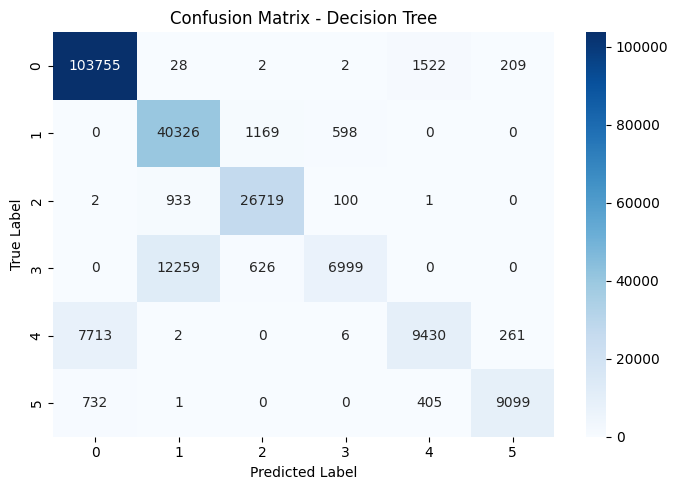

In [1]:
# ----------------------------------------------------
# IMPORTS Decision Tree
# ----------------------------------------------------
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# ----------------------------------------------------
# SPARK SESSION
# ----------------------------------------------------
spark = (
    SparkSession.builder
    .appName("MQTT_DecisionTree")
    .config("spark.driver.memory", "3g")
    .config("spark.executor.memory", "2g")
    .config("spark.sql.shuffle.partitions", "20")
    .config("spark.default.parallelism", "20")
    .getOrCreate()
)

# ----------------------------------------------------
# LOAD DATA
# ----------------------------------------------------
path = "/kaggle/input/mqtt-processed/part-00000-7b22535d-495b-4742-b4ee-112f08e809b0-c000.csv"
df = spark.read.csv(path, header=True, inferSchema=True)

# ----------------------------------------------------
# DROP CATEGORICAL COLUMNS
# ----------------------------------------------------
df = df.drop("tcp_flags", "mqtt_conack_flags", "mqtt_conflags", "mqtt_hdrflags", "label")

# ----------------------------------------------------
# NUMERICAL COLUMNS (FROM YOUR DATA)
# ----------------------------------------------------
numerical_cols = [
  'f_0', 'f_1', 'f_2', 'f_3', 'f_4', 'f_5',
    'f_6', 'f_7', 'f_8', 'f_9', 'f_10', 'f_11', 
]

LABEL_COL = "label_idx"

# Feature columns without label
feature_cols = [c for c in numerical_cols if c != LABEL_COL]

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
df = assembler.transform(df)

# ----------------------------------------------------
# SCALING
# ----------------------------------------------------
scaler = StandardScaler(inputCol="features", outputCol="scaled_features")
scaler_model = scaler.fit(df)
df = scaler_model.transform(df)

# ----------------------------------------------------
# TRAIN-TEST SPLIT
# ----------------------------------------------------
train_df, test_df = df.randomSplit([0.8, 0.2], seed=42)

# ----------------------------------------------------
# DECISION TREE MODEL
# ----------------------------------------------------
dt = DecisionTreeClassifier(
    featuresCol="scaled_features",
    labelCol=LABEL_COL,
    maxDepth=10,
    maxBins=64      # Prevent maxBin error
)

dt_model = dt.fit(train_df)

# ----------------------------------------------------
# PREDICTION
# ----------------------------------------------------
pred = dt_model.transform(test_df)
pred.select(LABEL_COL, "prediction", "probability").show(10)

# ----------------------------------------------------
# METRICS
# ----------------------------------------------------
evaluator_acc = MulticlassClassificationEvaluator(labelCol=LABEL_COL, predictionCol="prediction", metricName="accuracy")
evaluator_f1 = MulticlassClassificationEvaluator(labelCol=LABEL_COL, predictionCol="prediction", metricName="f1")
evaluator_precision = MulticlassClassificationEvaluator(labelCol=LABEL_COL, predictionCol="prediction", metricName="weightedPrecision")
evaluator_recall = MulticlassClassificationEvaluator(labelCol=LABEL_COL, predictionCol="prediction", metricName="weightedRecall")

print("Accuracy:", evaluator_acc.evaluate(pred))
print("F1 Score:", evaluator_f1.evaluate(pred))
print("Precision:", evaluator_precision.evaluate(pred))
print("Recall:", evaluator_recall.evaluate(pred))

# ----------------------------------------------------
# CONFUSION MATRIX PLOT
# ----------------------------------------------------
pdf = pred.select(LABEL_COL, "prediction").toPandas()

cm = confusion_matrix(pdf[LABEL_COL], pdf["prediction"])

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Decision Tree")
plt.tight_layout()
plt.show()


+---------+----------+--------------------+
|label_idx|prediction|         probability|
+---------+----------+--------------------+
|      1.0|       1.0|[0.0,1.0,0.0,0.0,...|
|      1.0|       1.0|[0.0,0.9994079336...|
|      1.0|       1.0|[0.0,0.9709432275...|
|      1.0|       1.0|[0.0,0.9994079336...|
|      1.0|       1.0|[0.0,0.9995442114...|
|      1.0|       1.0|[1.35464643727987...|
|      1.0|       1.0|[0.0,0.9995442114...|
|      1.0|       1.0|[0.0,0.9985652797...|
|      1.0|       1.0|[1.35464643727987...|
|      1.0|       1.0|[0.0,1.0,0.0,0.0,...|
+---------+----------+--------------------+
only showing top 10 rows



Accuracy: 0.8989766665619855


F1 Score: 0.8911431639461175


Precision: 0.8995915658885255


Recall: 0.8989766665619855


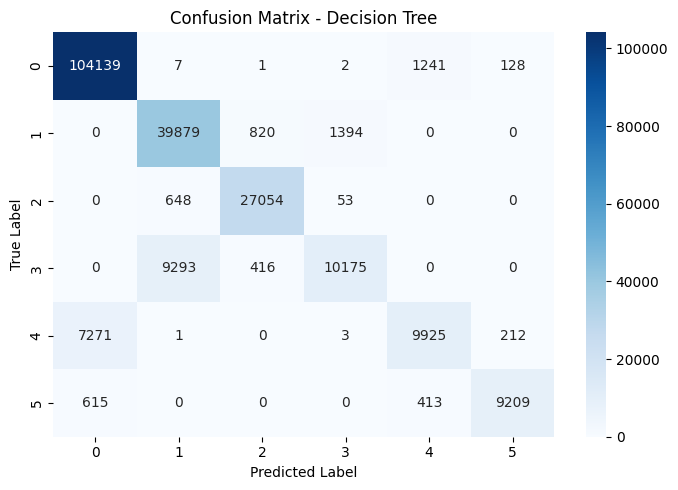

In [2]:
# ----------------------------------------------------
# IMPORTS Decision Tree
# ----------------------------------------------------
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# ----------------------------------------------------
# SPARK SESSION
# ----------------------------------------------------
spark = (
    SparkSession.builder
    .appName("MQTT_DecisionTree")
    .config("spark.driver.memory", "3g")
    .config("spark.executor.memory", "2g")
    .config("spark.sql.shuffle.partitions", "20")
    .config("spark.default.parallelism", "20")
    .getOrCreate()
)

# ----------------------------------------------------
# LOAD DATA
# ----------------------------------------------------
path = "/kaggle/input/mqtt-processed/part-00000-7b22535d-495b-4742-b4ee-112f08e809b0-c000.csv"
df = spark.read.csv(path, header=True, inferSchema=True)

# ----------------------------------------------------
# DROP CATEGORICAL COLUMNS
# ----------------------------------------------------
df = df.drop("tcp_flags", "mqtt_conack_flags", "mqtt_conflags", "mqtt_hdrflags", "label")

# ----------------------------------------------------
# NUMERICAL COLUMNS (FROM YOUR DATA)
# ----------------------------------------------------
numerical_cols = [
  'f_0', 'f_1', 'f_2', 'f_3', 'f_4', 'f_5',
    'f_6', 'f_7', 'f_8', 'f_9', 'f_10', 'f_11', 
]

LABEL_COL = "label_idx"

# Feature columns without label
feature_cols = [c for c in numerical_cols if c != LABEL_COL]

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
df = assembler.transform(df)

# ----------------------------------------------------
# SCALING
# ----------------------------------------------------
scaler = StandardScaler(inputCol="features", outputCol="scaled_features")
scaler_model = scaler.fit(df)
df = scaler_model.transform(df)

# ----------------------------------------------------
# TRAIN-TEST SPLIT
# ----------------------------------------------------
train_df, test_df = df.randomSplit([0.8, 0.2], seed=42)

# ----------------------------------------------------
# DECISION TREE MODEL
# ----------------------------------------------------
dt = DecisionTreeClassifier(
    featuresCol="scaled_features",
    labelCol=LABEL_COL,
    maxDepth=15,
    maxBins=128,
    minInstancesPerNode=5,
    minInfoGain=0.0,
    impurity="gini",
    seed=42
)


dt_model = dt.fit(train_df)

# ----------------------------------------------------
# PREDICTION
# ----------------------------------------------------
pred = dt_model.transform(test_df)
pred.select(LABEL_COL, "prediction", "probability").show(10)

# ----------------------------------------------------
# METRICS
# ----------------------------------------------------
evaluator_acc = MulticlassClassificationEvaluator(labelCol=LABEL_COL, predictionCol="prediction", metricName="accuracy")
evaluator_f1 = MulticlassClassificationEvaluator(labelCol=LABEL_COL, predictionCol="prediction", metricName="f1")
evaluator_precision = MulticlassClassificationEvaluator(labelCol=LABEL_COL, predictionCol="prediction", metricName="weightedPrecision")
evaluator_recall = MulticlassClassificationEvaluator(labelCol=LABEL_COL, predictionCol="prediction", metricName="weightedRecall")

print("Accuracy:", evaluator_acc.evaluate(pred))
print("F1 Score:", evaluator_f1.evaluate(pred))
print("Precision:", evaluator_precision.evaluate(pred))
print("Recall:", evaluator_recall.evaluate(pred))

# ----------------------------------------------------
# CONFUSION MATRIX PLOT
# ----------------------------------------------------
pdf = pred.select(LABEL_COL, "prediction").toPandas()

cm = confusion_matrix(pdf[LABEL_COL], pdf["prediction"])

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Decision Tree")
plt.tight_layout()
plt.show()


25/11/24 13:53:55 WARN DAGScheduler: Broadcasting large task binary with size 1102.7 KiB
25/11/24 13:54:00 WARN DAGScheduler: Broadcasting large task binary with size 1407.2 KiB
25/11/24 13:54:06 WARN DAGScheduler: Broadcasting large task binary with size 1769.0 KiB
25/11/24 13:54:12 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
25/11/24 13:54:20 WARN DAGScheduler: Broadcasting large task binary with size 2.6 MiB
25/11/24 13:54:28 WARN DAGScheduler: Broadcasting large task binary with size 1482.5 KiB
25/11/24 13:54:29 WARN DAGScheduler: Broadcasting large task binary with size 1491.2 KiB


+---------+----------+--------------------+
|label_idx|prediction|         probability|
+---------+----------+--------------------+
|      1.0|       1.0|[0.0,0.9974025974...|
|      1.0|       1.0|[0.0,0.9980554205...|
|      1.0|       1.0|[0.0,0.9964664310...|
|      1.0|       1.0|[0.0,0.9980554205...|
|      1.0|       1.0|[0.0,0.9973890339...|
|      1.0|       1.0|[0.0,0.9979545454...|
|      1.0|       1.0|[0.0,0.9973890339...|
|      1.0|       1.0|[0.0,1.0,0.0,0.0,...|
|      1.0|       1.0|[0.0,0.9979545454...|
|      1.0|       1.0|[0.0,0.9841269841...|
+---------+----------+--------------------+
only showing top 10 rows



Accuracy: 0.9190754556996666


25/11/24 13:54:36 WARN DAGScheduler: Broadcasting large task binary with size 1491.2 KiB


F1 Score: 0.914480274984053


25/11/24 13:54:43 WARN DAGScheduler: Broadcasting large task binary with size 1491.2 KiB
25/11/24 13:54:50 WARN DAGScheduler: Broadcasting large task binary with size 1491.2 KiB


Precision: 0.918942134044913


25/11/24 13:54:57 WARN DAGScheduler: Broadcasting large task binary with size 1473.5 KiB


Recall: 0.9190754556996668


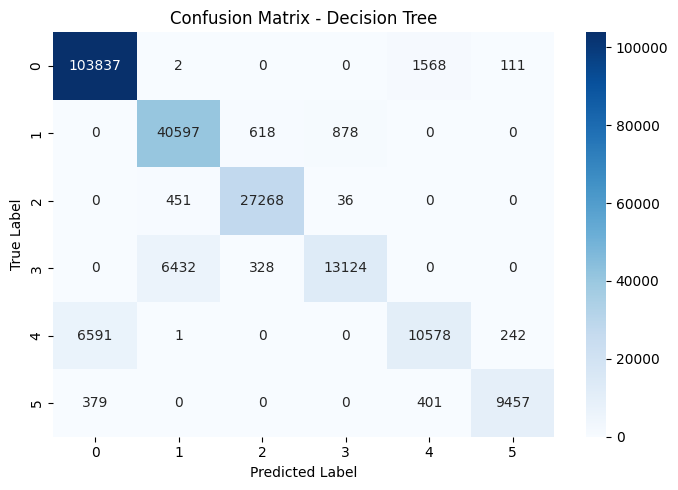

In [4]:
# ----------------------------------------------------
# IMPORTS Decision Tree
# ----------------------------------------------------
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# ----------------------------------------------------
# SPARK SESSION
# ----------------------------------------------------
spark = (
    SparkSession.builder
    .appName("MQTT_DecisionTree")
    .config("spark.driver.memory", "3g")
    .config("spark.executor.memory", "2g")
    .config("spark.sql.shuffle.partitions", "20")
    .config("spark.default.parallelism", "20")
    .getOrCreate()
)

# ----------------------------------------------------
# LOAD DATA
# ----------------------------------------------------
path = "/kaggle/input/mqtt-processed/part-00000-7b22535d-495b-4742-b4ee-112f08e809b0-c000.csv"
df = spark.read.csv(path, header=True, inferSchema=True)

# ----------------------------------------------------
# DROP CATEGORICAL COLUMNS
# ----------------------------------------------------
df = df.drop("tcp_flags", "mqtt_conack_flags", "mqtt_conflags", "mqtt_hdrflags", "label")

# ----------------------------------------------------
# NUMERICAL COLUMNS (FROM YOUR DATA)
# ----------------------------------------------------
numerical_cols = [
  'f_0', 'f_1', 'f_2', 'f_3', 'f_4', 'f_5',
    'f_6', 'f_7', 'f_8', 'f_9', 'f_10', 'f_11', 
]

LABEL_COL = "label_idx"

# Feature columns without label
feature_cols = [c for c in numerical_cols if c != LABEL_COL]

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
df = assembler.transform(df)

# ----------------------------------------------------
# SCALING
# ----------------------------------------------------
scaler = StandardScaler(inputCol="features", outputCol="scaled_features")
scaler_model = scaler.fit(df)
df = scaler_model.transform(df)

# ----------------------------------------------------
# TRAIN-TEST SPLIT
# ----------------------------------------------------
train_df, test_df = df.randomSplit([0.8, 0.2], seed=42)

# ----------------------------------------------------
# DECISION TREE MODEL
# ----------------------------------------------------
dt = DecisionTreeClassifier(
    featuresCol="scaled_features",
    labelCol=LABEL_COL,
    maxDepth=20,            # deeper tree → best accuracy/F1
    maxBins=256,            # prevents bin errors & improves splits
    minInstancesPerNode=2,  # allows detailed splits (good for large datasets)
    minInfoGain=0.0,        # allow maximum possible splitting
    impurity="gini",        # best for multi-class
    seed=42
)


dt_model = dt.fit(train_df)

# ----------------------------------------------------
# PREDICTION
# ----------------------------------------------------
pred = dt_model.transform(test_df)
pred.select(LABEL_COL, "prediction", "probability").show(10)

# ----------------------------------------------------
# METRICS
# ----------------------------------------------------
evaluator_acc = MulticlassClassificationEvaluator(labelCol=LABEL_COL, predictionCol="prediction", metricName="accuracy")
evaluator_f1 = MulticlassClassificationEvaluator(labelCol=LABEL_COL, predictionCol="prediction", metricName="f1")
evaluator_precision = MulticlassClassificationEvaluator(labelCol=LABEL_COL, predictionCol="prediction", metricName="weightedPrecision")
evaluator_recall = MulticlassClassificationEvaluator(labelCol=LABEL_COL, predictionCol="prediction", metricName="weightedRecall")

print("Accuracy:", evaluator_acc.evaluate(pred))
print("F1 Score:", evaluator_f1.evaluate(pred))
print("Precision:", evaluator_precision.evaluate(pred))
print("Recall:", evaluator_recall.evaluate(pred))

# ----------------------------------------------------
# CONFUSION MATRIX PLOT
# ----------------------------------------------------
pdf = pred.select(LABEL_COL, "prediction").toPandas()

cm = confusion_matrix(pdf[LABEL_COL], pdf["prediction"])

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Decision Tree")
plt.tight_layout()
plt.show()
